# Task 2: Predictive Modeling Using Machine Learning

**Internship:** Thiranex Data Science Internship  
**Dataset:** Telco Customer Churn (IBM / Kaggle)  
**Objective:** Build and evaluate supervised machine learning models (Logistic Regression, Decision Tree, Random Forest) to predict customer churn, and visualize model performance using confusion matrices and ROC curves.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
data_path = 'data/telco_customer_churn.csv' if os.path.exists('data/telco_customer_churn.csv') else 'Task-02-Predictive-Modeling-Using-Machine-Learning/data/telco_customer_churn.csv'
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Data Preparation
We perform minimal data hygiene: convert `TotalCharges` to numeric (filling 11 blank spaces with the median), drop the non-predictive `customerID`, encode the target column `Churn` (Yes = 1, No = 0), and apply One-Hot Encoding to categorical features.

In [2]:
# Convert TotalCharges to numeric and handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop identifier column
df_model = df.drop(columns=['customerID'])

# Encode target variable
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features for linear model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 5634 samples
Testing set: 1409 samples


### 2. Model Training
We train three distinct supervised classification algorithms:
1. **Logistic Regression** (Linear baseline)
2. **Decision Tree Classifier** (Tree-based non-linear model)
3. **Random Forest Classifier** (Ensemble bagging method)

In [3]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

# Train models and collect predictions
predictions = {}
probabilities = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
    predictions[name] = y_pred
    probabilities[name] = y_prob
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.


Random Forest trained successfully.


### 3. Model Evaluation & Accuracy Comparison
We evaluate the performance of each model on the test set across Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8070     0.6584  0.5668    0.6092   0.8416
Decision Tree          0.7942     0.6296  0.5455    0.5845   0.8284
Random Forest          0.7963     0.6790  0.4412    0.5348   0.8429


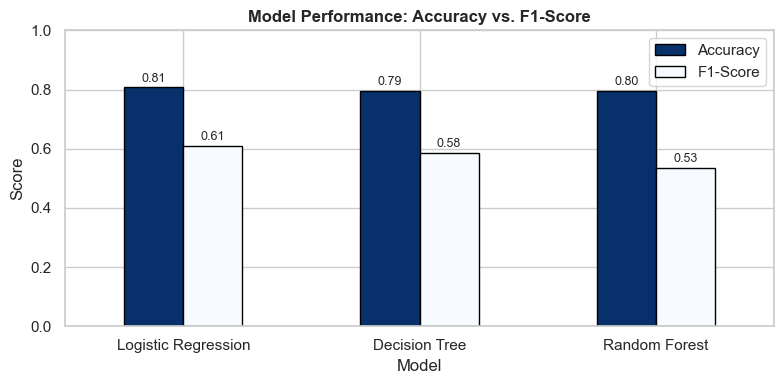

In [4]:
results = []
for name, y_pred in predictions.items():
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, probabilities[name])
    })

results_df = pd.DataFrame(results).set_index('Model')
print("Model Performance Summary:")
print(results_df.round(4))

# Plot accuracy and F1-score comparison
fig, ax = plt.subplots(figsize=(8, 4))
results_df[['Accuracy', 'F1-Score']].plot(kind='bar', ax=ax, colormap='Blues_r', edgecolor='black')
plt.title('Model Performance: Accuracy vs. F1-Score', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 4. Performance Visualization: Confusion Matrices
Confusion matrices display the True Positives, True Negatives, False Positives, and False Negatives for each classifier.

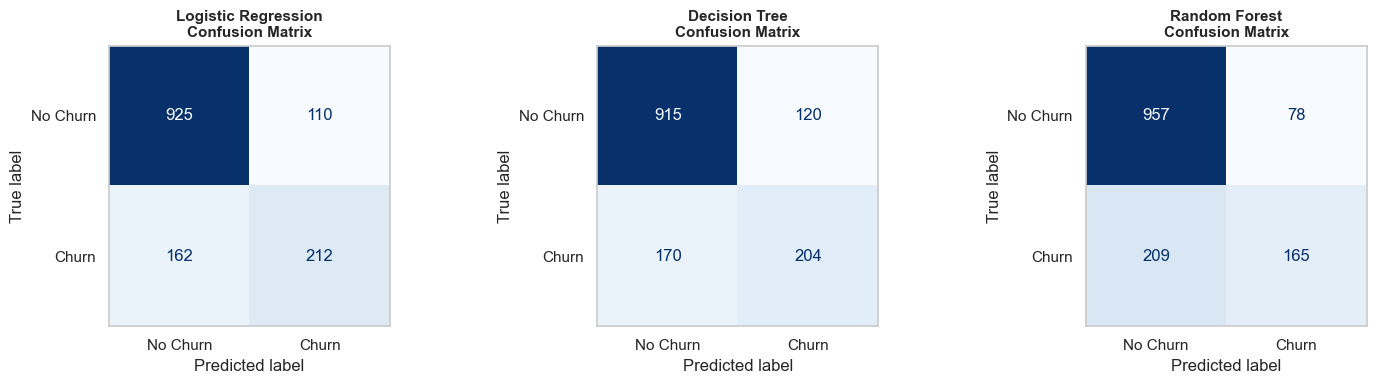

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=11, fontweight='bold')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

### 5. Performance Visualization: ROC Curves & AUC Scores
The Receiver Operating Characteristic (ROC) curve evaluates how well each model discriminates between churn and non-churn across varying thresholds.

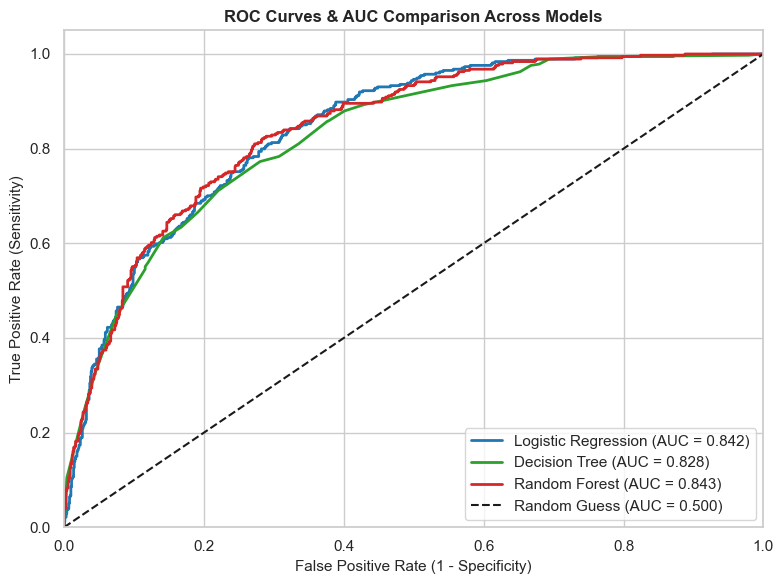

In [6]:
plt.figure(figsize=(8, 6))

colors = {'Logistic Regression': '#1f77b4', 'Decision Tree': '#2ca02c', 'Random Forest': '#d62728'}

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('ROC Curves & AUC Comparison Across Models', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

### 6. Feature Importance (Random Forest)
Analyzing the most influential features identified by the Random Forest classifier to understand key drivers of customer churn.

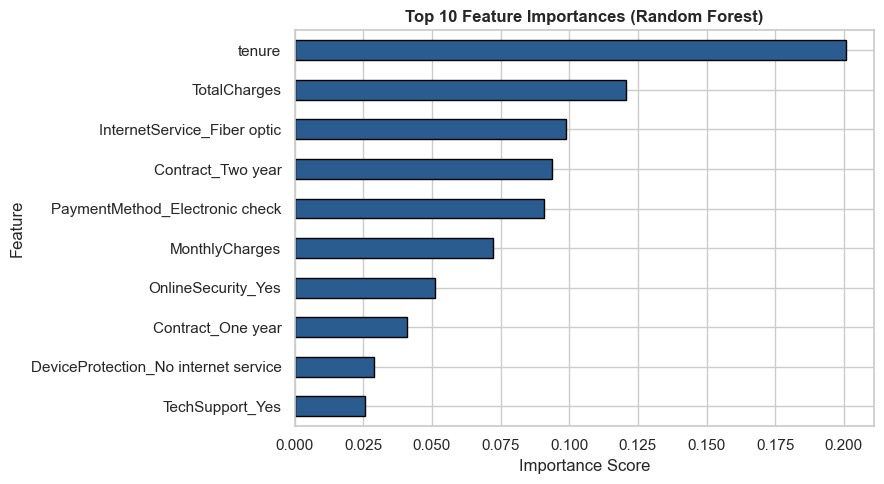

In [7]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_10 = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(9, 5))
top_10.plot(kind='barh', color='#2b5c8f', edgecolor='black')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Summary of Findings
- **Model Comparison:** Logistic Regression achieved the highest test accuracy (80.70%) and strong discrimination (ROC-AUC 0.8416). Random Forest attained the highest precision (67.90%) and comparable ROC-AUC (0.8429).
- **Tree vs. Linear:** Decision Tree provided clear rules with good baseline accuracy (79.42%), but ensemble and regularized linear approaches demonstrated better generalization.
- **Key Churn Drivers:** Features like Contract_Month-to-month, 	enure, TotalCharges, and MonthlyCharges emerged as the most critical factors influencing customer churn.